# LangChain Assignment — Intelligent Travel Assistant

## Create Tools

Here we create two custom tools which are wrappers on top of the [Tavily API](https://tavily.com/#api) and [WeatherAPI](https://www.weatherapi.com/)

- Web Search tool with information extraction
- Weather tool


In [2]:
import os
from tqdm import tqdm
from langchain.tools import tool
from markitdown import MarkItDown
from langchain_tavily import TavilySearch

import requests
tavily_tool = TavilySearch(max_results=7,
                            search_depth='advanced',
                            include_answers=False,
                            include_raw_content=True)

# certain websites won't let you crawl them unless you specify a user-agent
# pretending to be a real browser
session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/112.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br"
})

md = MarkItDown(requests_session=session)

In [15]:
from concurrent.futures import ThreadPoolExecutor, TimeoutError, as_completed
from bs4 import BeautifulSoup

MAX_CONTENT_CHARS = 3000  # hard cap to protect LLM latency

@tool
def get_top_attractions(destination: str) -> list:
    """Searches the web to find top tourist attractions and 
    points of interest for a given travel destination.
    Args:
        destination (str): The travel destination to search for attractions.
    Returns:
        list: A list of top tourist attractions and points of interest."""

    attractions_prompt = f"""
    Find the top tourist attractions and points of interest in {destination}.
    Include famous landmarks, cultural sites, natural attractions,
    and popular local experiences.
    Prioritize places that are highly rated, frequently visited,
    or considered must-see spots by travelers.
    Return a concise list with short descriptions.
    """

    results = tavily_tool.invoke(attractions_prompt)['results']
    docs = []

    def extract_content(url):
        try:
            response = session.get(url, timeout=8)
            response.raise_for_status()

            soup = BeautifulSoup(response.text, "lxml")

            title = (soup.title.string if soup.title else "").strip()

            # Remove junk
            for tag in soup(["script", "style", "noscript"]):
                tag.decompose()

            text = soup.get_text(separator=" ", strip=True)
            combined = f"{title}\n{text}"

            return combined[:MAX_CONTENT_CHARS]

        except Exception as e:
            print(f"⚠️ Failed to fetch {url}: {e}")
            return ""


    # def extract_content(url):
    #     extracted_info = md.convert(url)
    #     text_title = (extracted_info.title or "").strip()
    #     text_content = (extracted_info.text_content or "").strip()

    #     if not text_title and not text_content:
    #         return ""

    #     combined_text = text_title + "\n" + text_content
    #     return combined_text[:MAX_CONTENT_CHARS]

    def fallback_doc(result):
        text_title = (result.get('title') or "").strip()
        text_content = (result.get('content') or "").strip()
        combined_text = f"{text_title}\n{text_content}"
        return combined_text[:MAX_CONTENT_CHARS]

    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = {
            executor.submit(extract_content, result["url"]): result
            for result in results
        }

        for future in tqdm(as_completed(futures), total=len(futures)):
            result = futures[future]
            try:
                content = future.result(timeout=15)
                if content:
                    docs.append(content)
            except TimeoutError:
                print(f"Extraction timed out for url: {result['url']}")
                docs.append(fallback_doc(result))
            except Exception as e:
                print(f"Error extracting from url: {result['url']} - {e}")
                docs.append(fallback_doc(result))

    return {
        "destination": destination,
        "sources_used": len(docs),
        "documents": docs[:-1]  # capping can be done
    }

In [14]:
import requests

@tool
def get_weather(query: str) -> dict:
    """Search weatherapi to get the current weather.
     Args:
         query (str): The location to get the weather for.

     Returns:
         dict: The current weather data.
     """
    WEATHER_API_KEY=os.getenv("WEATHER_API_KEY")
    base_url = "http://api.weatherapi.com/v1/current.json"
    complete_url = f"{base_url}?key={WEATHER_API_KEY}&q={query}"

    response = requests.get(complete_url)
    data = response.json()
    if data.get("location"):
        return data
    else:
        return {
        "status": "not_found",
        "message": "Weather data not available"
    }


## Test Tools

In [4]:
import rich

response = get_weather.invoke('New Delhi')
rich.print(response)

{
    'location': {
        'name': 'New Delhi',
        'region': 'Delhi',
        'country': 'India',
        'lat': 28.6,
        'lon': 77.2,
        'tz_id': 'Asia/Kolkata',
        'localtime_epoch': 1767705894,
        'localtime': '2026-01-06 18:54'
    },
    'current': {
        'last_updated_epoch': 1767705300,
        'last_updated': '2026-01-06 18:45',
        'temp_c': 10.1,
        'temp_f': 50.2,
        'is_day': 0,
        'condition': {'text': 'Mist', 'icon': '//cdn.weatherapi.com/weather/64x64/night/143.png', 'code': 1030},
        'wind_mph': 4.9,
        'wind_kph': 7.9,
        'wind_degree': 330,
        'wind_dir': 'NNW',
        'pressure_mb': 1021.0,
        'pressure_in': 30.15,
        'precip_mm': 0.0,
        'precip_in': 0.0,
        'humidity': 87,
        'cloud': 25,
        'feelslike_c': 9.1,
        'feelslike_f': 48.5,
        'windchill_c': 17.8,
        'windchill_f': 64.0,
        'heatindex_c': 17.8,
        'heatindex_f': 64.0,
        'dewpoint_c': 0.4,
        'dewpoint_f': 32.7,
        'vis_km': 1.1,
        'vis_miles': 0.0,
        'uv': 0.0,
        'gust_mph': 9.2,
        'gust_kph': 14.8
    }
}

In [8]:
response = get_top_attractions.invoke('New Delhi')
for doc in response:
    rich.print(doc)
    rich.print("-------------------------------------------------------------------------")

 20%|██        | 1/5 [00:00<00:01,  3.06it/s]

Error extracting from url: https://www.viator.com/New-Delhi/d804 - 403 Client Error: Forbidden for url: https://www.viator.com/New-Delhi/d804


 40%|████      | 2/5 [00:01<00:01,  1.87it/s]

Error extracting from url: https://www.tripadvisor.com/Attractions-g304551-Activities-New_Delhi_National_Capital_Territory_of_Delhi.html - 403 Client Error: Forbidden for url: https://www.tripadvisor.com/Attractions-g304551-Activities-New_Delhi_National_Capital_Territory_of_Delhi.html


 80%|████████  | 4/5 [00:02<00:00,  1.42it/s]

...

-------------------------------------------------------------------------

What are the best places to visit in New Delhi, India? - Quora
Red Fort (Lal Qila): 17th-century Mughal fortress, impressive ramparts, evening light-and-sound show. Arrive early 
to avoid crowds; hire a licensed guide or use the official audio guide.
 Qutub Minar Complex: 73 m minaret (UNESCO), Iron Pillar, Alai Darwaza. Good for photography and an accessible 
half-day visit. Closed on certain holidays—check timings.
 Humayun’s Tomb: Mughal garden tomb that prefigures Taj Mahal architecture. Calm lawns, excellent at golden hour. 
[...] 1) Red Fort: 
Delhi's most famous monument, the Red Fort, stands not only as a powerful reminder of the Mughal era India but also
a symbol of India's struggle for freedom. It was billed by fifth Mughal emperor Shah Jahan, when he decided to 
shift his capital there from Agra in 1638. The fort's turbulent history includes being captured by the Sikhs and 
the British. To take your imagination back to the ancient era, a one hour sound and light show of the fort's 
history is held each evening. [...] Examples of itineraries (concise)

 Classic 2-day: Day 1 — Red Fort, Jama Masjid, Chandni Chowk (food walk), Raj Ghat; Day 2 — Qutub Minar, Humayun’s 
Tomb, Lodhi Gardens, Connaught Place.
 Culture & markets (3 days): Day 1 — Humayun + National Museum; Day 2 — Old Delhi exploration + Chandni Chowk food 
tour; Day 3 — Hauz Khas Village, Dilli Haat, Qutub/Mehrauli late afternoon.

-------------------------------------------------------------------------

Top 7 Iconic Landmarks of Delhi
2. Red Fort, once the pivot of the mighty Mughal Empire, is situated right alongside the banks of the Yamuna River.
The architectural majesty is very impressive piece of ancient architecture which date backs to seventeenth century.
Massive defensive walls greet you, sweeping over almost 2 km in length, with foreboding main gates and huge ward 
towers. The Red Fort was declared a ‘UNESCO World Heritage Site’ in 2007. It is one of the most popular of the 
Delhi tourist attractions and the tour [...] 3. Raj Ghat,is the place where India’s ‘Father of the Nation’ Mahatma 
Gandhi’s remains are buried. Mahatma Gandhi is best known for his philosophy of Non Violence or Amimsa. A visit to 
this serene memorial of Gandhi who inspired leaders like Martin Luther and Nelson Mandela is definitely recommended
as one of the iconic sites to visit in Delhi. The eternal flame of Raj Ghat marks a prominent memorial to Mahatma 
Gandhi but tributes to other major figures throughout India’s history, from [...] 6. India Gate, one of the topmost
iconic landmarks of Delhi, is a war memorial. Built in memory of the soldiers who sacrificed their lives fighting 
for the British Army in World War I, India Gate also gets large number of visitors. The names of the soldiers who 
died in these wars are inscribed on the walls. The area wears a magic charm with the floodlights during the night.

-------------------------------------------------------------------------

In [5]:
tools = [get_weather, get_top_attractions]
tools

[StructuredTool(name='get_weather', description='Search weatherapi to get the current weather.\n     Args:\n         query (str): The location to get the weather for.\n\n     Returns:\n         dict: The current weather data.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x7f0a644663b0>),
 StructuredTool(name='get_top_attractions', description='Searches the web to find top tourist attractions and \n    points of interest for a given travel destination.\n    Args:\n        destination (str): The travel destination to search for attractions.\n    Returns:\n        list: A list of top tourist attractions and points of interest.', args_schema=<class 'langchain_core.utils.pydantic.get_top_attractions'>, func=<function get_top_attractions at 0x7f0a64466320>)]

In [5]:
for tool in tools:
    print(tool.name, '->', tool.description)

get_weather -> Search weatherapi to get the current weather.
     Args:
         query (str): The location to get the weather for.

     Returns:
         dict: The current weather data.
get_top_attractions -> Searches the web to find top tourist attractions and 
    points of interest for a given travel destination.
    Args:
        destination (str): The travel destination to search for attractions.
    Returns:
        list: A list of top tourist attractions and points of interest.


## Create Travel Assistant ReAct Agent System Prompt

In [6]:
from langchain_core.messages import SystemMessage

AGENT_PREFIX = """Role:
You are an Intelligent Travel Assistant designed to help users plan travel by
reasoning over location and weather intent and by using tools when real-world
data is required.

Objective:
Provide accurate, helpful, and well-reasoned travel information including
weather insights (real or inferred), destination recommendations, best time
to visit, and top attractions, depending on user input.

Capabilities:
You have access to external tools that provide real-time information.
Use these tools intelligently based on what the user has explicitly or implicitly
provided in their query.
You may also use general geographic and seasonal knowledge when real-time data
is not required or not available.

------------------------------------------------
STEP 1: Query Analysis
------------------------------------------------

For every user query, determine:
1. Is a specific LOCATION provided?
2. Is WEATHER explicitly mentioned or implied?

Based on this analysis, classify the query into one of the flows below.

------------------------------------------------
SECTION 1: Location Provided
------------------------------------------------

Flow A — Location Provided, Weather Explicitly Mentioned
Examples:
- "What is the weather and places to visit in Paris?"
- "Is Jaipur hot right now and what can I see there?"

Behavior:
- Location is known.
- Weather information is required.

Actions:
1. Use `get_weather` to retrieve current weather for the location.
2. Use `get_top_attractions` to retrieve attractions for the same location.
3. Base the final response strictly on tool outputs.

------------------------------------------------

Flow B — Location Provided, Weather Not Mentioned
Examples:
- "What are the best places to visit in Kerala?"
- "Plan a trip to Rome"

Behavior:
- Location is known.
- Weather is NOT explicitly required.

Actions:
1. Use `get_top_attractions` to retrieve attractions.
2. Optionally use general seasonal knowledge to add context.
3. Call `get_weather` ONLY if:
   - Weather adds clear value, OR
   - The user implicitly expects current conditions.

Do NOT fabricate real-time weather if the tool is not used.

------------------------------------------------
SECTION 2: Location NOT Provided
------------------------------------------------

Flow C — Location Not Provided, Weather Mentioned or Implied
Examples:
- "Where should I go in India during summer?"
- "Suggest cold places to visit in May"
- "I want to avoid monsoon, where should I travel?"

Behavior:
- No specific location provided.
- Weather or season is central to the query.

Actions:
1. Use general climatological and geographic reasoning to infer suitable regions.
2. Treat weather as a conceptual or seasonal constraint, NOT real-time data.
3. Use `get_top_attractions` to discover destinations matching the inferred criteria.
4. Do NOT call `get_weather` unless a specific destination is later identified.

If needed, assume reasonable “dummy” weather context
(e.g., hill stations are cooler in summer), but clearly present it as inferred knowledge.

------------------------------------------------

Flow D — Location Not Provided, Weather Not Mentioned
Examples:
- "Suggest good travel destinations"
- "Where should I travel next?"

Behavior:
- Open-ended exploration query.

Actions:
1. Ask a brief clarifying question IF necessary
   (e.g., budget, season, region, experience).
2. If proceeding without clarification:
   - Suggest diverse destinations using `get_top_attractions`.
3. Do NOT call `get_weather`.

------------------------------------------------
STEP 2: Response Generation
------------------------------------------------

Generate a clear, well-structured response in markdown that:
- Explains recommendations logically
- Separates inferred knowledge from tool-based data
- Includes weather information ONLY if retrieved via `get_weather`
- Maintains a friendly, professional travel-assistant tone

------------------------------------------------
STRICT TOOL USAGE RULES
------------------------------------------------

- Use ONLY the tools explicitly provided.
- Never fabricate real-time weather data.
- Use inferred or dummy weather context ONLY for reasoning,
  not as factual current conditions.
- Always align tool usage with the classified flow.

"""

SYS_PROMPT = SystemMessage(content=AGENT_PREFIX)

## Create Travel Assistant ReAct Agent

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


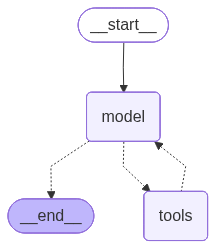

In [7]:
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

travel_assistant = create_agent(model=llm,
                                    tools=tools,
                                    system_prompt=SYS_PROMPT)
travel_assistant

## Test Travel Assistant ReAct Agent

In [14]:
from IPython.display import display, Markdown

for event in travel_assistant.stream(
    {"messages": [HumanMessage(content="I am planning a trip to Paris.")]},
    stream_mode='values' #returns full agent state with all messages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
mssg_type=event["messages"][-1].content[0]['type']
mssg_content=event["messages"][-1].content[0][mssg_type]
display(Markdown(mssg_content))

================================ Human Message =================================

I am planning a trip to Paris.
================================== Ai Message ==================================
Tool Calls:
  get_weather (b38dfe8a-c012-48c9-ae89-be4a3fd9361f)
 Call ID: b38dfe8a-c012-48c9-ae89-be4a3fd9361f
  Args:
    query: Paris
  get_top_attractions (e1757638-5f27-47f0-a42d-eabdd3ddfab5)
 Call ID: e1757638-5f27-47f0-a42d-eabdd3ddfab5
  Args:
    destination: Paris


 40%|████      | 2/5 [00:12<00:20,  6.82s/it]

Error extracting from url: https://www.mywanderlustylife.com/best-paris-bucket-list/ - 'NoneType' object has no attribute 'strip'


100%|██████████| 5/5 [00:22<00:00,  4.42s/it]


Error extracting from url: https://www.parisperfect.com/plan-your-trip/things-to-see/monuments-landmarks.php - 'NoneType' object has no attribute 'strip'
================================= Tool Message =================================
Name: get_top_attractions

["Paris Landmarks: Iconic Sites and Historical Treasures | Paris Insiders Guide\n[![Paris Insiders Guide](https://www.parisinsidersguide.com/image-files/header-fountain-dreamstime-2016-980x330.webp)](https://www.parisinsidersguide.com/)\n\n[![Paris Insiders Guide](https://www.parisinsidersguide.com/image-files/header-fountain-dreamstime-2016-700x330.webp)](https://www.parisinsidersguide.com/)\n\nMenu\n\n* What's On\n\n  #### [What's On in Paris](https://www.parisinsidersguide.com/things-to-do-in-paris.html)\n\n  [January 2026\n  in Paris](https://www.parisinsidersguide.com/things-to-do-in-paris-january.html)\n\n  [February 2026\n  in Paris](https://www.parisinsidersguide.com/things-to-do-in-paris-february.html)\n\n  [Paris Activ

Here's some information for your trip to Paris!

### Current Weather in Paris:
The weather in Paris is currently **Sunny** with a temperature of **2.3°C (36.1°F)**. It feels like 0.3°C (32.6°F) with a wind chill of -0.1°C (31.8°F). The humidity is at 80%, and there is no precipitation. Winds are blowing from the West-Northwest at 6.8 kph (4.3 mph).

### Top Attractions in Paris:
Paris offers a wealth of iconic landmarks and cultural sites to explore:

*   **The Eiffel Tower:** The quintessential symbol of Paris, offering spectacular city views.
*   **Louvre Museum:** Home to world-renowned masterpieces like the Mona Lisa and Venus de Milo.
*   **Palace of Versailles:** A magnificent royal palace and gardens, perfect for a day trip.
*   **Luxembourg Gardens:** Beautiful and extensive gardens surrounding the Luxembourg Palace.
*   **Musée d'Orsay:** Famous for its impressive collection of Impressionist and Post-Impressionist art.
*   **Cathedral of Notre-Dame:** A stunning example of French Gothic architecture, now reopened after restoration.
*   **Arc de Triomphe:** A monumental arch commemorating French victories, with panoramic views from its observation deck.
*   **Champs-Élysées:** The most famous avenue in Paris, known for luxury stores and grand architecture.
*   **Place de la Concorde:** Paris's largest public square, featuring impressive fountains and the Luxor Obelisk.
*   **Jardin des Tuileries:** Elegant gardens located between the Place de la Concorde and the Louvre.
*   **Sacré-Cœur Basilica:** A gleaming white basilica perched atop Montmartre, offering breathtaking city views.
*   **Palais Garnier:** An opulent 19th-century opera house, famous for its lavish interior.
*   **Sainte-Chapelle:** A Gothic chapel renowned for its stunning stained-glass windows.
*   **Moulin Rouge:** An iconic 19th-century cabaret, famous for its Belle Époque decor and the can-can.
*   **Panthéon:** A neoclassical building in the Latin Quarter, dedicated to honoring notable French figures.
*   **Père Lachaise Cemetery:** The largest cemetery in Paris and the most visited necropolis in the world, home to many famous graves.
*   **Jardin des Plantes:** The main botanical garden in Paris, featuring formal gardens, a labyrinth, and several museums.
*   **Les Invalides:** A complex of museums and monuments related to French military history, housing the Tomb of Napoleon Bonaparte.
*   **Seine River Cruises:** A fantastic way to see many of Paris's famous attractions from a unique perspective.
*   **Hôtel de la Marine:** A beautifully restored 18th-century building on Place de la Concorde.
*   **Hôtel de Ville:** The impressive Paris City Hall overlooking the Seine.
*   **Stravinsky Fountain:** A whimsical fountain next to Centre Pompidou with colorful, moving sculptures.
*   **Monnaie de Paris:** The world's oldest mint, offering a museum and art exhibitions.
*   **Chateau de Vincennes:** A historic fortress in eastern Paris.
*   **Hôtel de Sens:** A medieval mansion in the Marais district, now home to a public art library.
*   **Grand Palais:** A spectacular exhibition hall known for its glass roof.
*   **Pont des Arts:** A pedestrian bridge connecting the Louvre and the Institut de France, offering beautiful river views.
*   **Vaux-le-Vicomte:** A 17th-century chateau that inspired Versailles, located an hour from Paris.

Enjoy planning your exciting trip to Paris!

In [10]:
from IPython.display import display, Markdown

def call_travel_assistant_agent(query, verbose=False):

    for event in travel_assistant.stream(
        {"messages": [HumanMessage(content=query)]},
        stream_mode='values' #returns full agent state with all messages including updates
    ):
        if verbose:
            event["messages"][-1].pretty_print()

    print('\n\nFinal Response:\n')
    mssg_type=event["messages"][-1].content[0]['type']
    mssg_content=event["messages"][-1].content[0][mssg_type]
    display(Markdown(mssg_content))

In [11]:
call_travel_assistant_agent("I am planning a trip to Tokyo. Suggest place based on weather and attractions.", verbose=True)

================================ Human Message =================================

I am planning a trip to Tokyo. Suggest place based on weather and attractions.
================================== Ai Message ==================================
Tool Calls:
  get_weather (7863fe4c-d655-40ba-81de-776715c2191e)
 Call ID: 7863fe4c-d655-40ba-81de-776715c2191e
  Args:
    query: Tokyo
  get_top_attractions (469c2b0b-8071-4033-b924-585076c85857)
 Call ID: 469c2b0b-8071-4033-b924-585076c85857
  Args:
    destination: Tokyo


 14%|█▍        | 1/7 [00:00<00:02,  2.83it/s]

⚠️ Failed to fetch https://www.tripadvisor.com/Attractions-g298184-Activities-c47-Tokyo_Tokyo_Prefecture_Kanto.html: 403 Client Error: Forbidden for url: https://www.tripadvisor.com/Attractions-g298184-Activities-c47-Tokyo_Tokyo_Prefecture_Kanto.html


100%|██████████| 7/7 [00:02<00:00,  2.69it/s]


================================= Tool Message =================================
Name: get_top_attractions

["Top tourist attractions in Tokyo: the best sightseeing spots | The Official Tokyo Travel Guide, GO TOKYO\nTop tourist attractions in Tokyo: the best sightseeing spots | The Official Tokyo Travel Guide, GO TOKYO Skip to main content. GO TOKYO The Official Tokyo Travel Guide Travel Trade & Press School Trips Business Events NEW CALENDAR EXPERIENCES SPOT Listen Share this page Share this page Facebook X (Twitter) Email Copy URL EN Select Language æ¥æ¬èª ENGLISH ä¸­æ(ç®ä½) ä¸­æ(ç¹é«/æ­£é«) íê¸ à¸ à¸²à¸©à¸²à¹à¸à¸¢ DEUTSCH ITALIANO ESPAÑOL FRANÇAIS FAVORITES Search Detailed search: You can do a detailed search by keyword, genre, time, area and tag. Search by keywords Food & Drink Sports Nature Anime History & Culture Experiences Nightlife Events First day open calendar Final day open calendar By area Ginza Akihabara Tokyo Station & Marunouchi Nihonbashi Tsukiji Kanda

Here's some information for your trip to Tokyo, based on current weather and top attractions:

**Current Weather in Tokyo (as of 2026-01-07 00:47 JST):**
*   **Temperature:** 6.1°C (43°F)
*   **Feels like:** 3.9°C (39°F)
*   **Condition:** Partly cloudy
*   **Wind:** 10.4 kph (6.5 mph) from the North
*   **Humidity:** 49%

It's quite cool in Tokyo right now, so be sure to pack warm clothing.

**Top Attractions in Tokyo:**
Tokyo offers a vast array of attractions, blending rich history with modern culture. Here are some highly recommended places to visit:

*   **Sensoji Temple (Asakusa):** Tokyo's oldest temple, dating back to the 7th century. It's a tremendously popular destination with the iconic Kaminarimon Gate and Nakamise Dori, a souvenir shopping street leading to the main temple complex.
*   **Meiji Jingu:** A beautiful Shinto shrine dedicated to Emperor Meiji and Empress Shoken.
*   **Tsukiji Outer Market:** A vibrant market famous for its fresh seafood, produce, and culinary tools.
*   **Akihabara:** Known as the "Electric Town," this district is a hub for electronics, anime, manga, and otaku culture. On Sundays, the main street becomes a "pedestrian paradise."
*   **Gardens:**
    *   **Koishikawa Korakuen:** A stunning landscape garden next to Tokyo Dome.
    *   **Hama Rikyu Gardens:** Another beautiful landscape garden adjacent to Shiodome, offering a peaceful escape.
    *   **Imperial East Gardens:** A public park on the former grounds of Edo Castle.
*   **Imperial Palace:** The main residence of the Imperial Family (the inner grounds are generally not open to the public, but the East Garden is).
*   **Ginza:** Japan's premier shopping district, home to luxury boutiques, department stores, and fine dining.
*   **Tokyo Dome City:** An entertainment complex featuring an amusement park, shops, and restaurants around the Tokyo Dome stadium.

In [12]:
call_travel_assistant_agent("In India where I should visit during summer?", verbose=True)

================================ Human Message =================================

In India where I should visit during summer?
================================== Ai Message ==================================

[{'type': 'text', 'text': "During the summer months in India, it's best to visit hill stations to escape the heat of the plains. Here are a few recommendations for cooler destinations and their top attractions:", 'extras': {'signature': 'CtgIAXLI2nxmJU+TGfnXKRKxJB0IrgrxB6GYIiXBiqtJFXnqiMCbMo1T3qXurpKHlbRig3wTbJb2dUrW6LUjHNaS8CuwjQ0HQ3M/i7r535zb1i17h9M8LrCHY9g26Mlt4BzuyfckXhWPCZuP5l8vOnmrfOguXdNf4akL0EuAYIAcr0jM2+adiSb0NWbJSCiOtkReq4CUSRg7rO9XvqHw1aTPSKjtBiIZBNvPORuLfe3WaetBxCYn9zs02LjSIBgTOnbwac+M9mtF3d/rKLE0kKCGvJ2rrbUi2VEO93nDzrLQe2seNSzwnSYqehlws7OAZPuGVOmkDJkW0EFTe3c2u4IQ8bhGhD5U5HAqYZpnO2E+rUFRdYMVRZvFewqdT3TKV7l9JAszxVPhGqvwsq2vs496jpON5w1uzdrRSFPbOJ1puUSBXt0f3H5TOfhwjAjLwfMamB2yxhh/tZs0yJAcGBiNislnqkARZIDzN9p60Y8EK9xOTFRDcE/2I0vzGSPwnoCXtRrAr6Zy1yQWEIjFOnuuI61UiKvqtfDxgocoW

 43%|████▎     | 3/7 [00:01<00:01,  2.20it/s]

⚠️ Failed to fetch https://www.tripadvisor.com/Attractions-g297679-Activities-Ooty_Udhagamandalam_The_Nilgiris_District_Tamil_Nadu.html: 403 Client Error: Forbidden for url: https://www.tripadvisor.com/Attractions-g297679-Activities-Ooty_Udhagamandalam_The_Nilgiris_District_Tamil_Nadu.html


 57%|█████▋    | 4/7 [00:02<00:02,  1.36it/s]

⚠️ Failed to fetch https://www.tripadvisor.com/Attractions-g304552-Activities-Shimla_Shimla_District_Himachal_Pradesh.html: 403 Client Error: Forbidden for url: https://www.tripadvisor.com/Attractions-g304552-Activities-Shimla_Shimla_District_Himachal_Pradesh.html


...

⚠️ Failed to fetch https://www.ootyonline.in/guide/historical-monuments-in-ooty: HTTPSConnectionPool(host='www.ootyonline.in', port=443): Read timed out. (read timeout=8)




100%|██████████| 7/7 [00:08<00:00,  1.20s/it]

⚠️ Failed to fetch https://www.makemytrip.com/tripideas/heritage-manali: HTTPSConnectionPool(host='www.makemytrip.com', port=443): Read timed out. (read timeout=8)
================================= Tool Message =================================
Name: get_top_attractions

["\n�� ��������^K�����y���U;��c!�@�$���ނC�@8����1ǜ���&�3���jh�����}�Z���h�7#��V��N<����ڷwC�I��Q�+�a���� c�Km�4\n��s��nR�be�37�J�\nF��A9(Bi�y�E�Ę ʹ��u�+�B��K��\"KwǞ-�Aks���hu�e;\t%�k�x-���{�����;�����~��}价���.��*B�̓#�L��R�E)mO��p�o��d$��� ��>7qy��9,�Qk��Ge]�e�G`����FOP������.�C����h�q���q)���;�!ۋ���A�O]z��e确,�F̃��H*R2��{�Ѧ��(����M��;�PB����z����)�����B�����> {c�ψ�-�f����}ڛS�a;�7�7�9�\r`x�?~�|h����[��[�j���.�o~�ր�6��i�&[uk}�r�u<�7v���ӲL�4�� ���t��^�1l���-�~l�w{�Q��s1��]��Ӽ�7`�`�K�F�0�����p�:�>tl�o���~o ��]����V;ؼ�ޠ�n;�������a|�k����\\���u>���X�.�AǰL\\��{A?���N�3��^O��=V�n���pз:�1�;a?(=�px|��p��%�\r��8�~|q�Oy ������C�\\�J���Ϟ�ٲ�e���6��������ܢ���?� {Il}}λ�������No#ϸ}~���f�ǘ���<��nj-��O��]�E�!����?؟����������G<�ե���TR���

================================== Ai Message ==================================

[{'type': 'text', 'text': 'During the summer in India, hill stations are ideal for a cool and refreshing getaway. Here are three popular options with their top attractions:\n\n### 1. Shimla, Himachal Pradesh\nKnown as the "Queen of Hill Stations," Shimla offers a delightful escape from the summer heat.\n**Top Attractions:**\n*   **The Mall Road:** A vibrant hub for shopping, dining, and leisurely strolls with colonial-era architecture.\n*   **The Ridge:** A large open space alongside the Mall Road, hosting cultural activities and offering stunning views of the Himalayas. Christ Church, the second oldest church in Northern India, is located here.\n*   **Jakhoo Hill:** The highest peak in Shimla, offering panoramic views of the city and snow-capped mountains. It\'s home to an ancient Hanuman temple with a towering statue.\n*   **Kali Bari Temple:** Dedicated to Goddess Kali, it provides extensive views of t

During the summer in India, hill stations are ideal for a cool and refreshing getaway. Here are three popular options with their top attractions:

### 1. Shimla, Himachal Pradesh
Known as the "Queen of Hill Stations," Shimla offers a delightful escape from the summer heat.
**Top Attractions:**
*   **The Mall Road:** A vibrant hub for shopping, dining, and leisurely strolls with colonial-era architecture.
*   **The Ridge:** A large open space alongside the Mall Road, hosting cultural activities and offering stunning views of the Himalayas. Christ Church, the second oldest church in Northern India, is located here.
*   **Jakhoo Hill:** The highest peak in Shimla, offering panoramic views of the city and snow-capped mountains. It's home to an ancient Hanuman temple with a towering statue.
*   **Kali Bari Temple:** Dedicated to Goddess Kali, it provides extensive views of the surrounding areas.
*   **Annandale:** A picturesque flat terrain used as a racecourse during the British era, now a popular picnic spot.

### 2. Manali, Himachal Pradesh
Nestled in the Beas River Valley, Manali is a popular tourist destination known for its breathtaking natural beauty and adventure activities.
**Top Attractions:**
*   **Hadimba Devi Temple:** An ancient cave temple surrounded by cedar forests, dedicated to Hadimba Devi.
*   **Solang Valley:** Famous for adventure sports like paragliding, zorbing, and skiing (in winter).
*   **Rohtang Pass:** (Check accessibility during summer as it can sometimes be closed due to snow) Offers spectacular views and is a gateway to Lahaul and Spiti valleys.
*   **Old Manali:** A charming village distinct from New Manali, known for its relaxed vibe, guesthouses, and cafes.
*   **Beas River:** Enjoy riverside activities or simply relax by its gushing waters.

### 3. Ooty, Tamil Nadu
Often referred to as the "Queen of Nilgiris," Ooty in South India provides a cool climate and lush green landscapes.
**Top Attractions:**
*   **Ooty Lake:** An artificial lake where visitors can enjoy boating.
*   **Ooty Botanical Gardens:** Spread over 55 acres, these gardens feature a wide variety of plants, a fossil tree trunk, and host a flower show during the Ooty Summer Festival.
*   **Doddabetta Peak:** The highest point in the Nilgiri Mountains, offering panoramic views of the surrounding landscapes.
*   **Nilgiri Mountain Railway (Toy Train):** A UNESCO World Heritage Site, this historic train ride from Mettupalayam to Ooty offers picturesque views.
*   **Rose Garden:** Home to thousands of varieties of roses, it's a beautiful place to spend an afternoon.

These destinations are known for their pleasant weather during the Indian summer months, offering a cool respite and a variety of attractions to explore.

In [13]:
call_travel_assistant_agent("In India I am planning to visit south, when i should go suggest me best time to enjoy its peak beauty.", verbose=True)

================================ Human Message =================================

In India I am planning to visit south, when i should go suggest me best time to enjoy its peak beauty.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'For enjoying the peak beauty of South India, the best time to visit is generally from **October to March**. During these months, the weather is pleasant and comfortable, with less humidity and rainfall compared to the monsoon season (June to September). This period is ideal for exploring the diverse landscapes, cultural sites, and beaches of South India.', 'extras': {'signature': 'CrgJAXLI2nzZhyMKqWbS/uXaIWOCqoaQqANo4BaYwfdldIhc0P8KnpDFb0XuJJBDxBSyvf1l9X/IXoPcerDciqEUIuKz9jfeoh1BsoyCryAX6ItYeP7Zq0sQhgtZWTfAb7ADYcridmEH8EIxa36IgpeYy+yU+vdPK9wqGa0tjzRMUO/YJH7BUxK0mXhbiPxZ48LiHBuooMVGLehsjJteljcXsqQ48JWOSUyVW6QmpQsnvVrqgkVX37RUESmFG2zatpzsMrB4Eh2DO7q70+7yoYorrLN1OnS+krcFgdj0cnnk62p5os4C10iELZeuXdnJuf

For enjoying the peak beauty of South India, the best time to visit is generally from **October to March**. During these months, the weather is pleasant and comfortable, with less humidity and rainfall compared to the monsoon season (June to September). This period is ideal for exploring the diverse landscapes, cultural sites, and beaches of South India.